In [3]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

# Load Pantheon+ SN metadata
print("Loading Pantheon+ supernova data...")
df_pantheon = pd.read_csv(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat",
    "data/Pantheon+SH0ES.dat",
    sep=r"\s+"
)

print("Loading SN covariance matrix...")
n_sn = len(df_pantheon)

# Load .cov file with NumPy, skipping the first line (which contains just "1701")
cov_flat = np.loadtxt(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov",
    "data/Pantheon+SH0ES_STAT+SYS.cov",
    skiprows=1
)

# Reshape into square matrix
cov_matrix = cov_flat.reshape((n_sn, n_sn))

# Confirm shape is correct
assert cov_matrix.shape == (n_sn, n_sn), f"Expected ({n_sn},{n_sn}), got {cov_matrix.shape}"

# Invert covariance and pre-compute log-determinant for SN likelihood
global Cov_inv, logdetCov
Cov_inv = np.linalg.inv(cov_matrix)
sign, logdet = np.linalg.slogdet(cov_matrix)
if sign <= 0:
    raise ValueError("Covariance matrix is not positive-definite!")
logdetCov = logdet
print("Data loaded. Running joint cosmographic fits...")


Loading quasar data...


Reading quasars from HDF5: 100%|██████████| 1479/1479 [00:06<00:00, 215.52it/s]


Number of quasars loaded: 1479
Columns with NaNs: []
Number of quasars with 0 < z <= 1: 349
Number of quasars with z > 3: 81
Final number of quasars: 1477
Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Data loaded. Running joint cosmographic fits...


In [17]:
print("Loading quasar data...")
df_agn = load_quasar_data()

df_agn_f = df_agn.sample(n=100, random_state=42).reset_index(drop=True)

Loading quasar data...


Reading quasars from HDF5: 100%|██████████| 1479/1479 [00:44<00:00, 33.22it/s]


Number of quasars loaded: 1479
Columns with NaNs: []
Number of quasars with 0 < z <= 1: 349
Number of quasars with z > 3: 81
Final number of quasars: 1477


In [20]:
df_agn['apparent_mag_i'].max()

np.float32(22.823149)

In [ ]:
cosmo_model = 'Flatw0waCDM'
sampler_joint, _ = run_mcmc_pipeline(df_agn, df_pantheon, cosmo_model=cosmo_model, only_sna=False, completeness=True, use_full_cov=False)

100%|██████████| 100/100 [05:19<00:00,  3.20s/it]


/home/dutra/dev/eztaox/tutorials/hubble_plotting.py:245: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


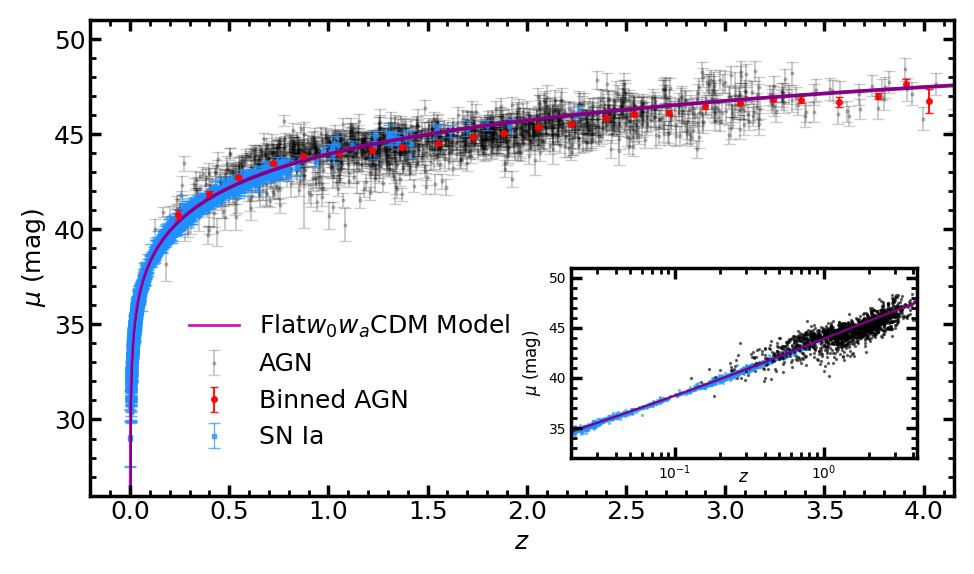

(array([ 0.1758599 , -0.0612166 ,  0.30868955, ...,  1.35447587,
         0.1658666 ,  0.50554922], shape=(1477,)),
 0       0.348270
 1       0.327243
 2       0.262453
 3       0.393870
 4       0.444134
           ...   
 1474    0.403819
 1475    0.438174
 1476    0.270438
 1477    0.568517
 1478    0.486564
 Length: 1477, dtype: float64)

In [4]:
plot_hubble(sampler_joint, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True)

Generating corner plot: 100%|██████████| 4/4 [00:22<00:00,  5.51s/it]


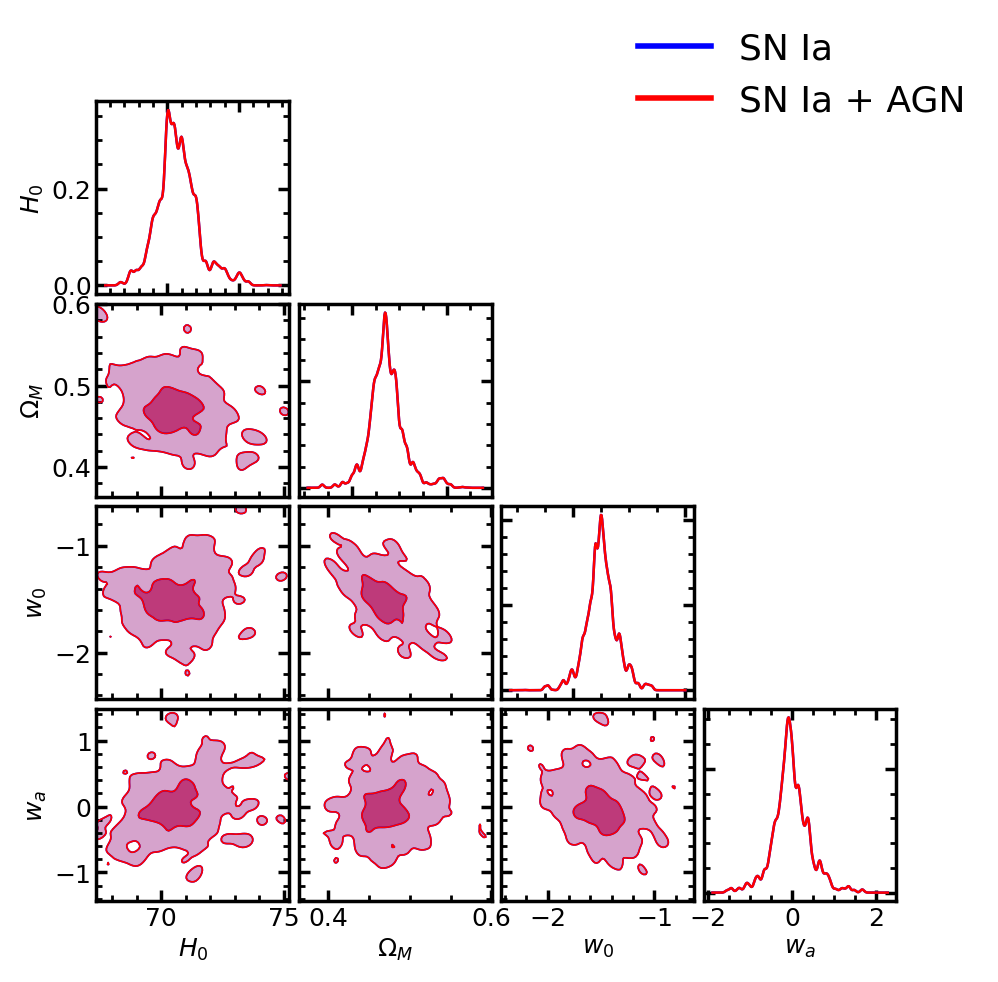

In [6]:
plot_cosmo_corner(sampler_joint, sampler_joint, cosmo_model=cosmo_model, show=True)

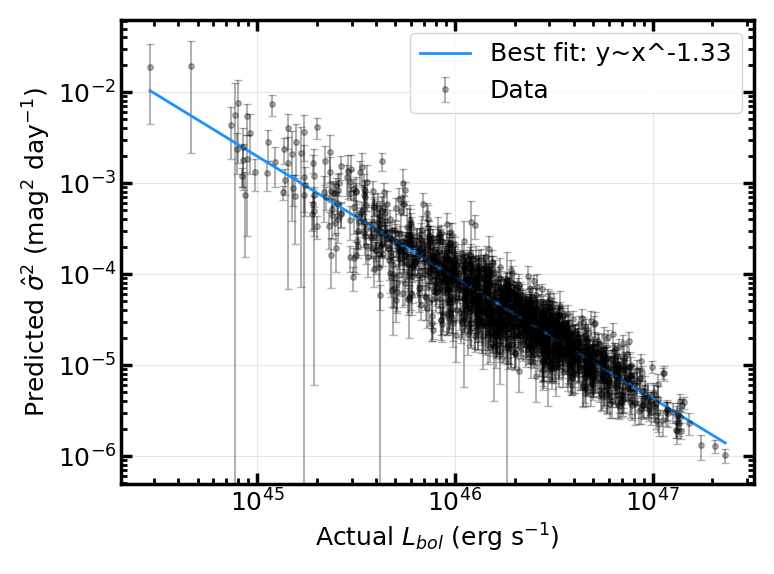

In [50]:
from scipy.stats import linregress

from hubble_plotting import plot_predicted_vs_actual_loglbol, plot_sigma_hat_sq_vs_lbol
plot_sigma_hat_sq_vs_lbol(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)
#plot_predicted_vs_actual_loglbol(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)

In [15]:
quasar_list = read_quasars_from_hdf5("data/may8_lc_all.h5")


Reading quasars from HDF5: 100%|██████████| 38825/38825 [02:20<00:00, 275.41it/s]


In [16]:
df_agn = pd.DataFrame(quasar_list)

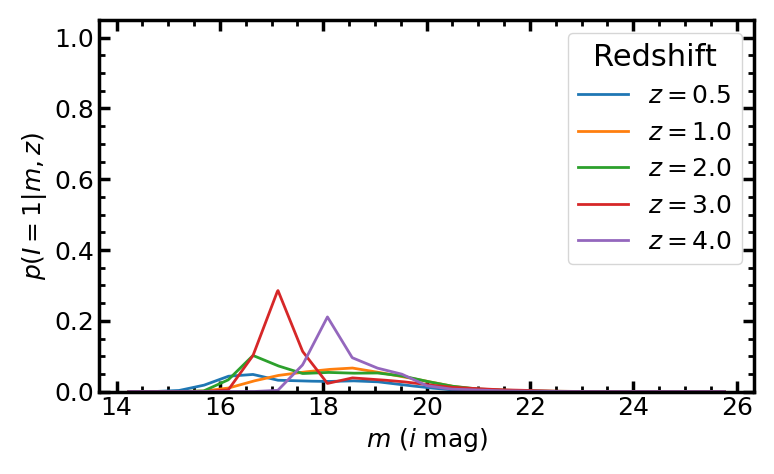

In [22]:
from hubble_utils import *
from hubble_plotting import *

#df_agn = load_quasar_data()
p_detect, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
plot_completeness_vs_mag_at_redshifts(p_detect, mag_centers, z_centers, show=True)